=== 1. MEMUAT DATA ===
Total data: 3189 baris
Train size: 2551 | Test size: 638

=== 2. MELATIH MODEL ARIMA ===

=== 3. MELATIH MODEL LSTM (MURNI) ===
Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0053 - val_loss: 4.6714e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 9.8994e-04 - val_loss: 0.0012
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 6.9739e-04 - val_loss: 0.0015
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 6.1965e-04 - val_loss: 2.1943e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.5398e-04 - val_loss: 2.3603e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.1664e-04 - val_loss: 2.3928e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 4.3833e-04 - val_loss: 2.9415e-04

=== 4. MELATIH MODEL HYBRID ===
Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0355 - val_loss: 0.0030
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0073 - val_loss: 0.003

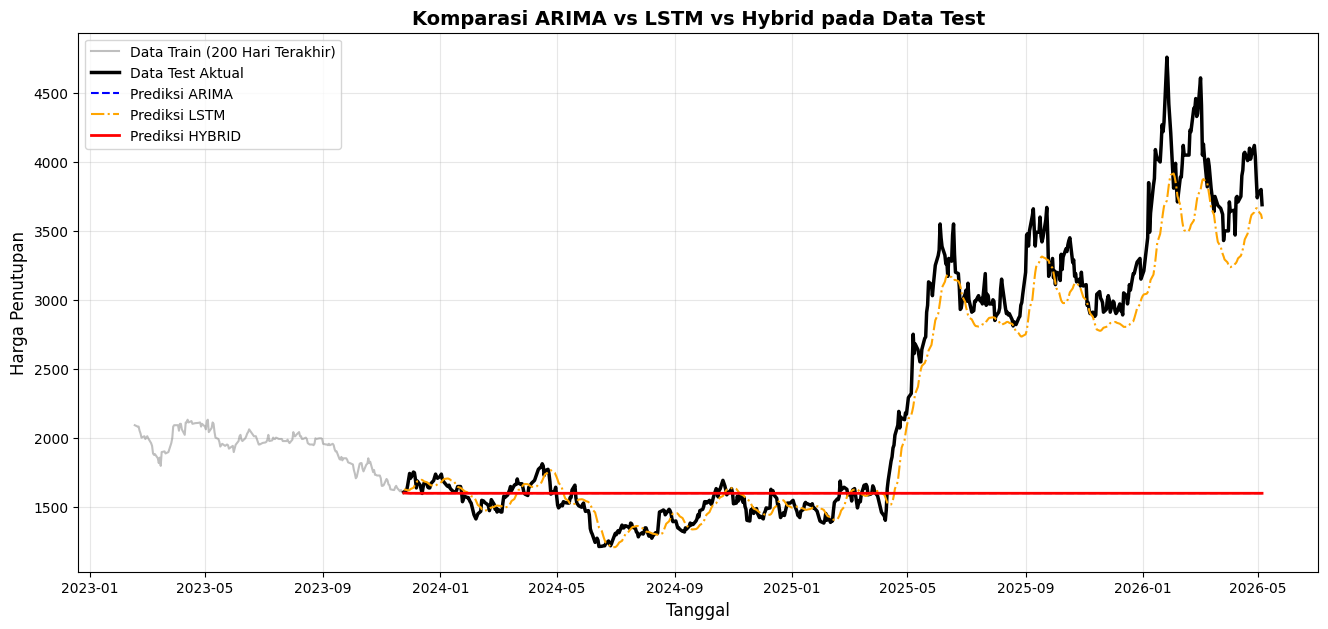


Menjalankan Forecast 5 Tahun ke Depan...
-> Fitting ARIMA ke Seluruh Data (Mencari model yang lebih baik)...
-> Memprediksi Residual Masa Depan (LSTM)...
-> Memprediksi Harga Masa Depan (LSTM Murni)...


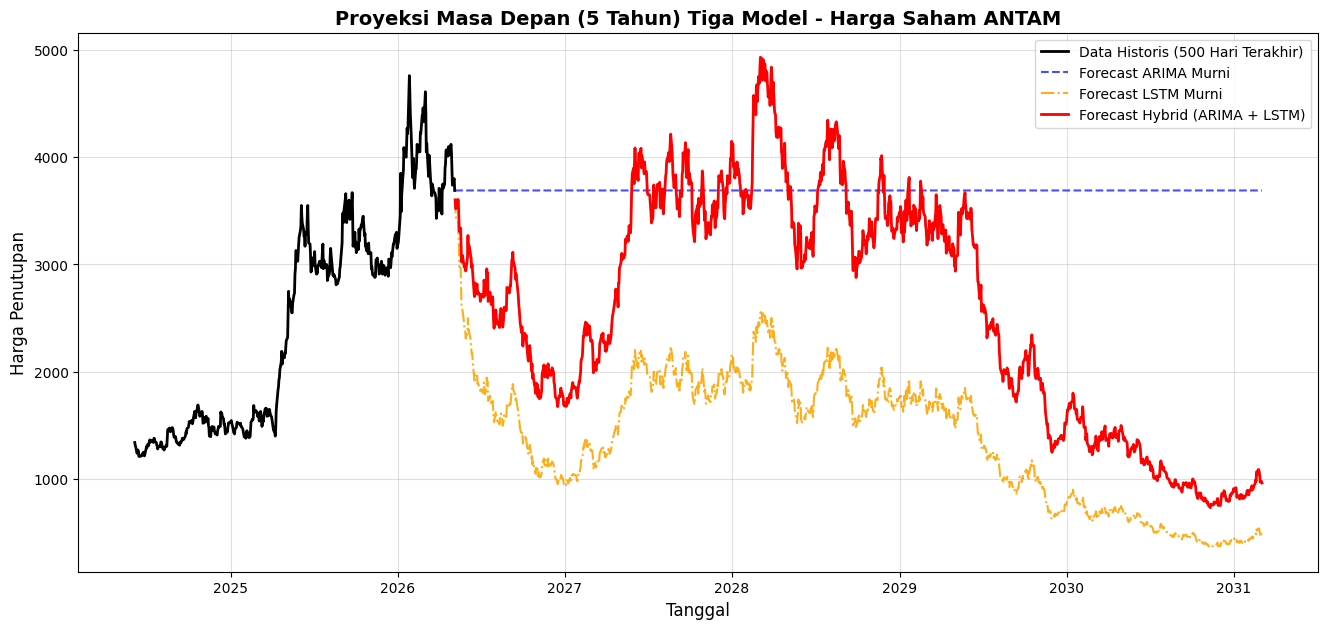


RINGKASAN PERFORMA MODEL DARI DATA TEST (EXPECTED ERROR)
1. ARIMA Murni  -> RMSE: 1187.24 | MAE: 810.99 | MAPE: 26.73%
2. LSTM Murni   -> RMSE: 230.69 | MAE: 153.03 | MAPE: 5.81%
3. HYBRID       -> RMSE: 1187.92 | MAE: 811.24 | MAPE: 26.72%

Forecast 5 tahun untuk ketiga model selesai!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# 1. LOAD & PREP DATA
# ==========================================================
print("=== 1. MEMUAT DATA ===")
df = pd.read_csv('../data/processed/data_antam_clean.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df.set_index('Tanggal', inplace=True)
df = df.sort_index()

price_col = 'Terakhir'
if df[price_col].dtype == 'object':
    df[price_col] = df[price_col].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

df = df.dropna(subset=[price_col])
series = df[[price_col]].rename(columns={price_col: "price"}).dropna()
series = series.asfreq("B") # Asumsi hari bursa (Business days)
series["price"] = series["price"].interpolate()

print(f"Total data: {len(series)} baris")

# ==========================================================
# 2. TRAIN - TEST SPLIT (80% / 20%)
# ==========================================================
train_ratio = 0.8
split_idx = int(len(series) * train_ratio)

train = series.iloc[:split_idx]
test  = series.iloc[split_idx:]

print(f"Train size: {len(train)} | Test size: {len(test)}")

# Fungsi Evaluasi (RMSE, MAE, MAPE)
def calculate_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    # Menghindari division by zero pada MAPE
    mape = np.mean(np.abs((actual - pred) / (actual + 1e-10))) * 100
    return rmse, mae, mape

# Fungsi Pembentuk Sekuens (Sliding Window)
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60

# ==========================================================
# 3. MODEL 1: ARIMA (MURNI)
# ==========================================================
print("\n=== 2. MELATIH MODEL ARIMA ===")
arima_model = auto_arima(
    train["price"],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=5, max_q=5
)

arima_train_fitted = arima_model.predict_in_sample()
arima_test_pred = arima_model.predict(n_periods=len(test))

arima_train_fitted = pd.Series(arima_train_fitted, index=train.index)
arima_test_pred = pd.Series(arima_test_pred, index=test.index)

# ==========================================================
# 4. MODEL 2: LSTM (MURNI)
# ==========================================================
print("\n=== 3. MELATIH MODEL LSTM (MURNI) ===")
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled_series = scaler_lstm.fit_transform(series.values.reshape(-1, 1))

X_full_lstm, y_full_lstm = create_sequences(scaled_series, window_size)

# Split sequence sesuai batas train dan test
split_seq_idx = split_idx - window_size
X_train_lstm = X_full_lstm[:split_seq_idx]
y_train_lstm = y_full_lstm[:split_seq_idx]
X_test_lstm = X_full_lstm[split_seq_idx:]
y_test_lstm = y_full_lstm[split_seq_idx:]

X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

model_lstm_murni = Sequential([
    LSTM(128, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.1),
    LSTM(64, return_sequences=False),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm_murni.compile(optimizer='adam', loss='mean_squared_error')

# Menghentikan epoch otomatis jika validation loss semakin tinggi (memburuk)
early_stop_lstm = EarlyStopping(
    monitor='val_loss', 
    patience=3, # Toleransi 3 epoch jika loss naik sebelum akhirnya di stop
    restore_best_weights=True
)

model_lstm_murni.fit(
    X_train_lstm, y_train_lstm, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[early_stop_lstm], 
    verbose=1
)

# Prediksi LSTM Murni
lstm_test_pred_scaled = model_lstm_murni.predict(X_test_lstm, verbose=0)
lstm_test_pred = scaler_lstm.inverse_transform(lstm_test_pred_scaled).flatten()
lstm_test_pred = pd.Series(lstm_test_pred, index=test.index)

# ==========================================================
# 5. MODEL 3: HYBRID (ARIMA + LSTM RESIDUAL)
# ==========================================================
print("\n=== 4. MELATIH MODEL HYBRID ===")
# Hitung residual dari ARIMA di data latih
train_residual = train["price"] - arima_train_fitted
train_residual = train_residual.dropna()

scaler_res = MinMaxScaler(feature_range=(-1, 1))
scaled_train_residual = scaler_res.fit_transform(train_residual.values.reshape(-1, 1))

X_train_res, y_train_res = create_sequences(scaled_train_residual, window_size)
X_train_res = np.reshape(X_train_res, (X_train_res.shape[0], X_train_res.shape[1], 1))

model_hybrid_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.1),
    LSTM(64, return_sequences=False),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model_hybrid_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Menghentikan epoch otomatis jika validation loss semakin tinggi (memburuk)
early_stop_res = EarlyStopping(
    monitor='val_loss', 
    patience=3, # Toleransi 3 epoch jika loss naik sebelum akhirnya di stop
    restore_best_weights=True
)

model_hybrid_lstm.fit(
    X_train_res, y_train_res, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[early_stop_res], 
    verbose=1
)

# Prediksi Residual di Masa Test (Iteratif Out-of-Sample)
test_residual_preds = []
current_batch_res = scaled_train_residual[-window_size:].reshape((1, window_size, 1))

for i in range(len(test)):
    next_pred_res = model_hybrid_lstm.predict(current_batch_res, verbose=0)
    test_residual_preds.append(next_pred_res[0, 0])
    current_batch_res = np.append(current_batch_res[:, 1:, :], [[next_pred_res[0]]], axis=1)

test_residual_preds = scaler_res.inverse_transform(np.array(test_residual_preds).reshape(-1, 1)).flatten()
lstm_res_test_pred = pd.Series(test_residual_preds, index=test.index)

# GABUNGAN HYBRID: Prediksi ARIMA + Prediksi Residual LSTM
hybrid_test_pred = arima_test_pred + lstm_res_test_pred


# ==========================================================
# 6. KOMPARASI & EVALUASI METRIK
# ==========================================================
arima_rmse, arima_mae, arima_mape = calculate_metrics(test["price"], arima_test_pred)
lstm_rmse, lstm_mae, lstm_mape = calculate_metrics(test["price"], lstm_test_pred)
hybrid_rmse, hybrid_mae, hybrid_mape = calculate_metrics(test["price"], hybrid_test_pred)

print("\n" + "="*50)
print("HASIL KOMPARASI METRIK KETIGA MODEL PADA DATA TEST")
print("="*50)
print(f"1. ARIMA Murni")
print(f"   RMSE : {arima_rmse:.2f}")
print(f"   MAE  : {arima_mae:.2f}")
print(f"   MAPE : {arima_mape:.2f}%")
print("-" * 50)
print(f"2. LSTM Murni")
print(f"   RMSE : {lstm_rmse:.2f}")
print(f"   MAE  : {lstm_mae:.2f}")
print(f"   MAPE : {lstm_mape:.2f}%")
print("-" * 50)
print(f"3. HYBRID (ARIMA + LSTM)")
print(f"   RMSE : {hybrid_rmse:.2f}")
print(f"   MAE  : {hybrid_mae:.2f}")
print(f"   MAPE : {hybrid_mape:.2f}%")
print("="*50)

# ==========================================================
# 7. PLOT PERBANDINGAN KETIGA MODEL
# ==========================================================
plt.figure(figsize=(16, 7))
plt.plot(train.index[-200:], train["price"].iloc[-200:], label="Data Train (200 Hari Terakhir)", color="gray", alpha=0.5)
plt.plot(test.index, test["price"], label="Data Test Aktual", color="black", linewidth=2.5)

plt.plot(arima_test_pred.index, arima_test_pred, label="Prediksi ARIMA", linestyle="--", color="blue")
plt.plot(lstm_test_pred.index, lstm_test_pred, label="Prediksi LSTM", linestyle="-.", color="orange")
plt.plot(hybrid_test_pred.index, hybrid_test_pred, label="Prediksi HYBRID", color="red", linewidth=2)

plt.title("Komparasi ARIMA vs LSTM vs Hybrid pada Data Test", fontsize=14, fontweight='bold')
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga Penutupan", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# 8. FORECAST MASA DEPAN (5 TAHUN)
# ==========================================================
print("\nMenjalankan Forecast 5 Tahun ke Depan...")
horizon_days = 1260 # 5 tahun (Asumsi 252 hari bursa/tahun)

# Tanggal ke depan (hanya hari kerja bursa)
future_index = pd.bdate_range(start=series.index[-1] + pd.Timedelta(days=1), periods=horizon_days)

# A. RETRAIN ARIMA LEBIH ROBUST
# Kita ubah sedikit parameter auto_arima agar lebih "memaksa" mencari stasioneritas
print("-> Fitting ARIMA ke Seluruh Data (Mencari model yang lebih baik)...")
arima_full = auto_arima(
    series["price"], 
    seasonal=False, 
    stepwise=True, 
    suppress_warnings=True, 
    error_action="ignore",
    start_p=1, start_q=1,
    max_p=7, max_q=7, # Memperluas ruang pencarian
    d=None # Biarkan model mencari derajat differencing terbaik
)
arima_future = pd.Series(arima_full.predict(n_periods=horizon_days), index=future_index)

# Dapatkan residual dari full data untuk bekal LSTM
full_fitted = pd.Series(arima_full.predict_in_sample(), index=series.index)
full_residual = series["price"] - full_fitted
scaled_full_res = scaler_res.fit_transform(full_residual.dropna().values.reshape(-1, 1))

# B. PROYEKSI RESIDUAL DENGAN LSTM (UNTUK HYBRID)
print("-> Memprediksi Residual Masa Depan (LSTM)...")
future_res_preds = []
current_batch_fut = scaled_full_res[-window_size:].reshape((1, window_size, 1))

for i in range(horizon_days):
    next_pred_fut = model_hybrid_lstm.predict(current_batch_fut, verbose=0)
    future_res_preds.append(next_pred_fut[0, 0])
    current_batch_fut = np.append(current_batch_fut[:, 1:, :], [[next_pred_fut[0]]], axis=1)

future_res_preds = scaler_res.inverse_transform(np.array(future_res_preds).reshape(-1, 1)).flatten()
lstm_future_res = pd.Series(future_res_preds, index=future_index)

# C. PENGGABUNGAN HYBRID (ARIMA + LSTM Residual)
hybrid_future_base = arima_future + lstm_future_res

# D. PROYEKSI DENGAN LSTM MURNI
print("-> Memprediksi Harga Masa Depan (LSTM Murni)...")
scaled_full_series = scaler_lstm.transform(series.values.reshape(-1, 1))
current_batch_lstm = scaled_full_series[-window_size:].reshape((1, window_size, 1))
future_lstm_preds = []

for i in range(horizon_days):
    next_pred_lstm = model_lstm_murni.predict(current_batch_lstm, verbose=0)
    future_lstm_preds.append(next_pred_lstm[0, 0])
    current_batch_lstm = np.append(current_batch_lstm[:, 1:, :], [[next_pred_lstm[0]]], axis=1)

future_lstm_preds = scaler_lstm.inverse_transform(np.array(future_lstm_preds).reshape(-1, 1)).flatten()
lstm_future_base = pd.Series(future_lstm_preds, index=future_index)

# E. Menerapkan Random Walk dengan Drift (Geometric Brownian Motion) 
# Untuk LSTM Murni & Hybrid agar realistis
historical_volatility = df['Terakhir'].pct_change().std()
last_actual_price = df['Terakhir'].iloc[-1]

realistic_hybrid = []
realistic_lstm = []
curr_price_hybrid = last_actual_price
curr_price_lstm = last_actual_price

for i in range(len(future_index)):
    # Drift Hybrid
    if i == 0:
        drift_hybrid = (hybrid_future_base.iloc[i] - last_actual_price) / last_actual_price
        drift_lstm = (lstm_future_base.iloc[i] - last_actual_price) / last_actual_price
    else:
        drift_hybrid = (hybrid_future_base.iloc[i] - hybrid_future_base.iloc[i-1]) / hybrid_future_base.iloc[i-1]
        drift_lstm = (lstm_future_base.iloc[i] - lstm_future_base.iloc[i-1]) / lstm_future_base.iloc[i-1]
        
    # Batasi drift ekstrem
    drift_hybrid = np.clip(drift_hybrid, -0.015, 0.015)
    drift_lstm = np.clip(drift_lstm, -0.015, 0.015)
    
    # Kombinasikan dengan noise pasar yang sama untuk kedua model
    noise = np.random.normal(0, historical_volatility)
    
    curr_price_hybrid = curr_price_hybrid * (1 + drift_hybrid + noise)
    curr_price_lstm = curr_price_lstm * (1 + drift_lstm + noise)
    
    # Guardrail bawah
    if curr_price_hybrid < 10: curr_price_hybrid = 10
    if curr_price_lstm < 10: curr_price_lstm = 10
        
    realistic_hybrid.append(curr_price_hybrid)
    realistic_lstm.append(curr_price_lstm)

hybrid_future = pd.Series(realistic_hybrid, index=future_index, name="hybrid_future")
lstm_future = pd.Series(realistic_lstm, index=future_index, name="lstm_future")

# F. PLOT HASIL 5 TAHUN KE DEPAN UNTUK SEMUA MODEL
plt.figure(figsize=(16, 7))
plt.plot(series.index[-500:], series["price"].iloc[-500:], label="Data Historis (500 Hari Terakhir)", color="black", linewidth=2)
plt.plot(arima_future.index, arima_future, label="Forecast ARIMA Murni", linestyle="--", color="blue", alpha=0.7)
plt.plot(lstm_future.index, lstm_future, label="Forecast LSTM Murni", linestyle="-.", color="orange", alpha=0.9)
plt.plot(hybrid_future.index, hybrid_future, label="Forecast Hybrid (ARIMA + LSTM)", color="red", linewidth=2)

plt.title("Proyeksi Masa Depan (5 Tahun) Tiga Model - Harga Saham ANTAM", fontsize=14, fontweight='bold')
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga Penutupan", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.4)
plt.show()

print("\n" + "="*50)
print("RINGKASAN PERFORMA MODEL DARI DATA TEST (EXPECTED ERROR)")
print("="*50)
print(f"1. ARIMA Murni  -> RMSE: {arima_rmse:.2f} | MAE: {arima_mae:.2f} | MAPE: {arima_mape:.2f}%")
print(f"2. LSTM Murni   -> RMSE: {lstm_rmse:.2f} | MAE: {lstm_mae:.2f} | MAPE: {lstm_mape:.2f}%")
print(f"3. HYBRID       -> RMSE: {hybrid_rmse:.2f} | MAE: {hybrid_mae:.2f} | MAPE: {hybrid_mape:.2f}%")
print("="*50)

print("\nForecast 5 tahun untuk ketiga model selesai!")